In [1]:
import torch.nn as nn
import torch
import torch.nn.functional as F
from tqdm import tqdm 

In [29]:
tipo_de_escola =   torch.tensor([0, 0, 0, 1, 1, 1, 1])
escolaridade_mae = torch.tensor([0, 1, 1, 0, 0, 2, 2])
nota =           torch.tensor([5, 3, 2, 7, 9, 8, 7]).float()



In [6]:
embedding = nn.Embedding(
    num_embeddings=2,
    embedding_dim=3,
)

linear = nn.Linear(
    in_features=3,
    out_features=1,
)
e = embedding(tipo_de_escola)
saida = linear(e)
print(saida)

tensor([[-0.0525],
        [-0.0525],
        [-0.0525],
        [-0.3065],
        [-0.3065],
        [-0.3065],
        [-0.3065]], grad_fn=<AddmmBackward0>)


In [26]:
class MyModel( nn.Module ):
    def __init__( self, num_embeddings_escola, num_embeddings_escolaridade_mae, embedding_dim ):
        super().__init__()
        self.embedding_escola = nn.Embedding(
        num_embeddings=num_embeddings_escola,
        embedding_dim=embedding_dim,
        )
        
        self.embedding_escolaridade_mae = nn.Embedding(
        num_embeddings=num_embeddings_escolaridade_mae,
        embedding_dim=embedding_dim,
        )

        self.linear1 = nn.Linear(
            in_features=embedding_dim,
            out_features=embedding_dim,
        )
        self.relu1 = nn.ReLU()
        
        self.linear2 = nn.Linear(
            in_features=embedding_dim,
            out_features=1,
        )
        

    
    def forward( self, tipo_de_escola, escolaridade_da_mae ):
        e_escola = self.embedding_escola(tipo_de_escola)
        e_mae = self.embedding_escolaridade_mae(escolaridade_da_mae)
        
        e = e_escola + e_mae
        y = self.linear1(e)
        y = self.relu1(y)
        y = self.linear2(y)
        return y

In [34]:
model = MyModel(num_embeddings_escola=2, num_embeddings_escolaridade_mae=3, embedding_dim=2)
model(tipo_de_escola, escolaridade_mae)

tensor([[ 0.0569],
        [-0.0956],
        [-0.0956],
        [ 0.0346],
        [ 0.0346],
        [-0.3382],
        [-0.3382]], grad_fn=<AddmmBackward0>)

In [35]:
print(model)

MyModel(
  (embedding_escola): Embedding(2, 2)
  (embedding_escolaridade_mae): Embedding(3, 2)
  (linear1): Linear(in_features=2, out_features=2, bias=True)
  (relu1): ReLU()
  (linear2): Linear(in_features=2, out_features=1, bias=True)
)


In [36]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
)  # lr is the learning rate - this is our alpha

print("Entering loop")
# And now, this is the training loop:
losses = []
for epoch in tqdm(range(2000)):
    optimizer.zero_grad()
    z_pred = model(tipo_de_escola, escolaridade_mae)
    loss = F.mse_loss(
        z_pred,
        nota,
    )
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

Entering loop


  0%|          | 0/2000 [00:00<?, ?it/s]/tmp/ipykernel_4097/716199480.py:12: UserWarning: Using a target size (torch.Size([7])) that is different to the input size (torch.Size([7, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(
100%|██████████| 2000/2000 [00:01<00:00, 1180.08it/s]


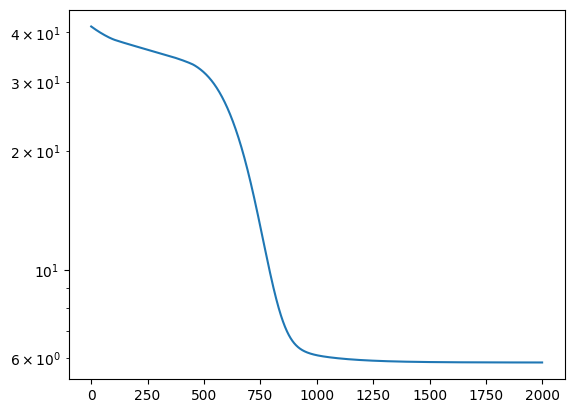

In [37]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(losses)
plt.semilogy()
plt.show()

In [39]:
model.embedding_escola.weight

Parameter containing:
tensor([[1.8213, 1.0328],
        [1.0774, 1.4740]], requires_grad=True)

In [40]:
model.embedding_escolaridade_mae.weight

Parameter containing:
tensor([[-0.3157,  0.8876],
        [-0.9061,  1.2521],
        [ 0.1880,  0.6174]], requires_grad=True)